In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(39).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(22).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(62).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(52).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(33).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(68).jpg
/kaggle/input/datasets/abid074/guavadiseasedat

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset, random_split
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
fruit_classes = ['Phytopthora', 'Scab', 'Styler and Root']

# Transforms for DeiT
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_guava_data(path):
    ds = datasets.ImageFolder(path, transform=transform)
    class_to_idx = {cls: i for i, cls in enumerate(fruit_classes)}
    new_samples = [(p, class_to_idx[ds.classes[l]]) for p, l in ds.samples if ds.classes[l] in fruit_classes]
    ds.samples, ds.imgs, ds.classes, ds.class_to_idx = new_samples, new_samples, fruit_classes, class_to_idx
    return ds

base = '/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1'
path1 = os.path.join(base, 'Guava Dataset (Original Image)/Guava Dataset (Original Image)')
path2 = os.path.join(base, 'Guava Disease( Augmented Image)/Guava Disease( Augmented Image)')

full_ds = ConcatDataset([load_guava_data(path1), load_guava_data(path2)])
train_set, val_set, test_set = random_split(full_ds, [int(0.7*len(full_ds)), int(0.15*len(full_ds)), len(full_ds)-int(0.7*len(full_ds))-int(0.15*len(full_ds))])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [5]:
# Load the 'tiny' version of DeiT for faster training
model = torch.hub.load('facebookresearch/deit:main', 'deit_tiny_patch16_224', pretrained=True)

# Replace the classifier head
num_ftrs = model.head.in_features
model.head = nn.Linear(num_ftrs, 3) 

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00003) # Transformers need a smaller Learning Rate

print("DeiT Model is ready.")

Downloading: "https://github.com/facebookresearch/deit/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/root/.cache/torch/hub/facebookresearch_deit_main/models.py:62: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/root/.cache/torch/hub/facebookresearch_deit_main/models.py:77: UserWarning: Overwriting deit_small_patch16_224 in registry with models.deit_small_patch16_224. This is

Downloading: "https://dl.fbaipublicfiles.com/deit/deit_tiny_patch16_224-a1311bcf.pth" to /root/.cache/torch/hub/checkpoints/deit_tiny_patch16_224-a1311bcf.pth


100%|██████████| 21.9M/21.9M [00:00<00:00, 142MB/s] 


DeiT Model is ready.


In [6]:
num_epochs = 10

print(f"{'Epoch':<6} | {'Tr. Loss':<10} | {'Tr. Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10}")
print("-" * 65)

for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    running_loss, running_corrects = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_set)
    epoch_acc = running_corrects.double() / len(train_set)

    # --- VALIDATION ---
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_set)
    epoch_val_acc = val_corrects.double() / len(val_set)

    # PRINTING PER EPOCH REQUIREMENTS
    print(f"{epoch+1:<6} | {epoch_loss:<10.4f} | {epoch_acc:<10.4f} | {epoch_val_loss:<10.4f} | {epoch_val_acc:<10.4f}")

print("\nTraining Complete!")

Epoch  | Tr. Loss   | Tr. Acc    | Val Loss   | Val Acc   
-----------------------------------------------------------------
1      | 0.2273     | 0.9206     | 0.0863     | 0.9706    
2      | 0.0275     | 0.9946     | 0.0432     | 0.9853    
3      | 0.0035     | 1.0000     | 0.0325     | 0.9916    
4      | 0.0012     | 1.0000     | 0.0320     | 0.9916    
5      | 0.0007     | 1.0000     | 0.0326     | 0.9916    
6      | 0.0005     | 1.0000     | 0.0330     | 0.9916    
7      | 0.0004     | 1.0000     | 0.0335     | 0.9916    
8      | 0.0003     | 1.0000     | 0.0342     | 0.9916    
9      | 0.0002     | 1.0000     | 0.0347     | 0.9916    
10     | 0.0002     | 1.0000     | 0.0352     | 0.9916    

Training Complete!


In [7]:
model.eval()
test_corrects = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

final_test_acc = (test_corrects.double() / len(test_set)) * 100
print(f"✅ FINAL TEST ACCURACY: {final_test_acc:.2f}%")

# Save the transformer model
torch.save(model.state_dict(), 'deit_guava_disease_transformer.pth')
print("Model Saved Successfully!")

✅ FINAL TEST ACCURACY: 98.74%
Model Saved Successfully!


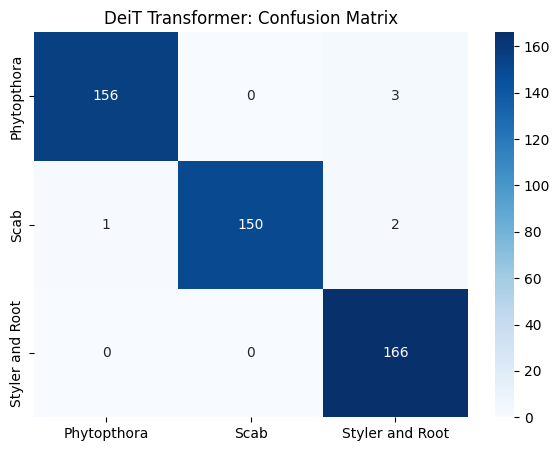

                 precision    recall  f1-score   support

    Phytopthora       0.99      0.98      0.99       159
           Scab       1.00      0.98      0.99       153
Styler and Root       0.97      1.00      0.99       166

       accuracy                           0.99       478
      macro avg       0.99      0.99      0.99       478
   weighted avg       0.99      0.99      0.99       478



In [8]:
all_p, all_l = [], []
model.eval()
with torch.no_grad():
    for img, lbl in test_loader:
        img = img.to(device)
        out = model(img)
        _, p = torch.max(out, 1)
        all_p.extend(p.cpu().numpy())
        all_l.extend(lbl.numpy())

cm = confusion_matrix(all_l, all_p)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=fruit_classes, yticklabels=fruit_classes)
plt.title('DeiT Transformer: Confusion Matrix')
plt.show()

print(classification_report(all_l, all_p, target_names=fruit_classes))

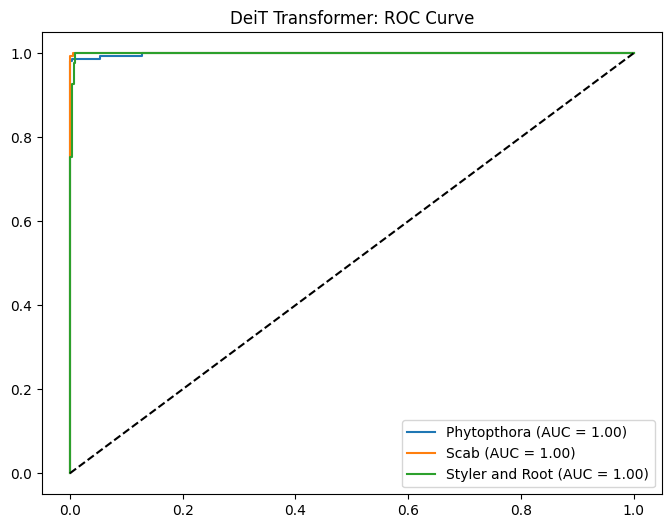

In [9]:
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for img, lbl in test_loader:
        img = img.to(device)
        out = model(img)
        all_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
        all_labels.extend(lbl.numpy())

bin_labels = label_binarize(all_labels, classes=[0, 1, 2])
plt.figure(figsize=(8,6))
for i in range(3):
    fpr, tpr, _ = roc_curve(bin_labels[:, i], np.array(all_probs)[:, i])
    plt.plot(fpr, tpr, label=f'{fruit_classes[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('DeiT Transformer: ROC Curve')
plt.legend()
plt.show()

In [10]:
import os

# Define the base path
base_path = '/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1'

# Define the two main directories
folders = {
    "Original": "Guava Dataset (Original Image)/Guava Dataset (Original Image)",
    "Augmented": "Guava Disease( Augmented Image)/Guava Disease( Augmented Image)"
}

# Define the specific classes
classes = ['Phytopthora', 'Scab', 'Styler and Root']

print(f"{'Folder Type':<12} | {'Class Name':<18} | {'Count':<6}")
print("-" * 45)

total_images = 0

for folder_label, sub_path in folders.items():
    full_folder_path = os.path.join(base_path, sub_path)
    
    for cls in classes:
        # Construct path to the specific disease folder
        class_path = os.path.join(full_folder_path, cls)
        
        if os.path.exists(class_path):
            # Count only files (images)
            count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
            print(f"{folder_label:<12} | {cls:<18} | {count:<6}")
            total_images += count
        else:
            print(f"{folder_label:<12} | {cls:<18} | Folder Not Found")

print("-" * 45)
print(f"{'TOTAL IMAGES':<33} | {total_images}")

Folder Type  | Class Name         | Count 
---------------------------------------------
Original     | Phytopthora        | 114   
Original     | Scab               | 106   
Original     | Styler and Root    | 94    
Augmented    | Phytopthora        | 942   
Augmented    | Scab               | 864   
Augmented    | Styler and Root    | 1063  
---------------------------------------------
TOTAL IMAGES                      | 3183
